# Лекция. Визуализация в seaborn

In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## § 1. Почему мы больше не рисуем вручную

На прошлой лекции мы освоили matplotlib. Это мощный, но низкоуровневый инструмент. Он даёт полный контроль, но цена этого контроля — объём кода. Каждую ось, каждую подпись, каждый цвет — всё приходится прописывать вручную.

В этой лекции мы познакомимся с seaborn — библиотекой, которая берёт на себя рутину. Но чтобы понять её ценность, мы сначала пройдём через примеры «плохого» кода на matplotlib, а потом увидим, как те же задачи решаются в seaborn.

Скачаем датафрейм:

In [2]:
df = pd.read_csv('data/df_cafe.csv')
df

,client_id,age,gender,loyalty,hour,weekday,drink_category,order_total,is_morning,is_friday_evening
0,382,41,Женский,1,6,Вс,Кофе,389.04,1,0
1,456,54,Мужской,1,17,Ср,Кофе,391.10,0,0
2,409,54,Мужской,1,12,Пн,Кофе,291.39,0,0
3,185,56,Мужской,0,18,Пн,Кофе,335.40,0,0
4,289,52,Мужской,1,6,Ср,Кофе,451.20,1,0
...,...,...,...,...,...,...,...,...,...,...
495,377,46,Мужской,1,10,Пн,Смузи,400.43,1,0
496,318,62,Женский,1,16,Чт,Чай,304.38,0,0
497,302,50,Мужской,1,12,Сб,Чай,425.65,0,0
498,36,61,Мужской,1,8,Вт,Кофе,403.09,1,0


#### Контекст

Датафрейм `df` содержит данные о покупках в сети кофеен. Датафрейм создан искусственно, с помощью генератора. Это не «грязный реальный лог», а чистый синтетический датасет.

#### Описание признаков

- client_id — уникальный идентификатор клиента (int64),
- age — возраст клиента (int64),
- gender — пол клиента (мужской / женский) (str),
- loyalty — флаг участия в программе лояльности (1 — участник, 0 — нет) (int64),
- hour — час совершения покупки (6–22) (int64),
- weekday — день недели (Пн, Вт, Ср, Чт, Пт, Сб, Вс) (str),
- drink_category — категория напитка (например, кофе, чай, смузи) (str),
- order_total — сумма чека, руб. (float64),
- is_morning — флаг утреннего времени (6:00–10:00): 1 — да, 0 — нет (int64),
- is_friday_evening — флаг пятничного вечера (18:00–20:00): 1 — да, 0 — нет (int64).

### Пример 1. Столбчатая диаграмма: средний чек по дням недели

Допустим, мы хотим визуализировать среднюю сумму покупки по дням недели. У нас есть датафрейм `df` с колонками `'weekday'` и `'order_total'`.

#### Подход matplotlib (героический, но мучительный)

Нам нужно выполнить несколько действий:

1) сгруппировать данные и посчитать средние вручную,

2) извлечь названия дней и значения,

3) построить столбцы.


Во-первых, нам понадобится группировка:

In [3]:
instruction = {'order_total': 'mean'}
daily_mean = df.groupby('weekday').agg(instruction)
daily_mean

,order_total
weekday,
Вс,323.823256
Вт,331.833913
Пн,310.101707
Пт,333.454563
Сб,323.547778
Ср,289.515373
Чт,331.099390


Затем колонку `'weekday'` мы выведем из индекса:

In [4]:
daily_mean = daily_mean.reset_index(drop = False)
daily_mean = daily_mean.reset_index(drop = True)
daily_mean

,weekday,order_total
0,Вс,323.823256
1,Вт,331.833913
2,Пн,310.101707
3,Пт,333.454563
4,Сб,323.547778
5,Ср,289.515373
6,Чт,331.099390


После этого мы получим доступ к нужным нам колонкам:

In [5]:
days = daily_mean['weekday']
values = daily_mean['order_total']

И только после этого сможем приступить к рисованию картинки:

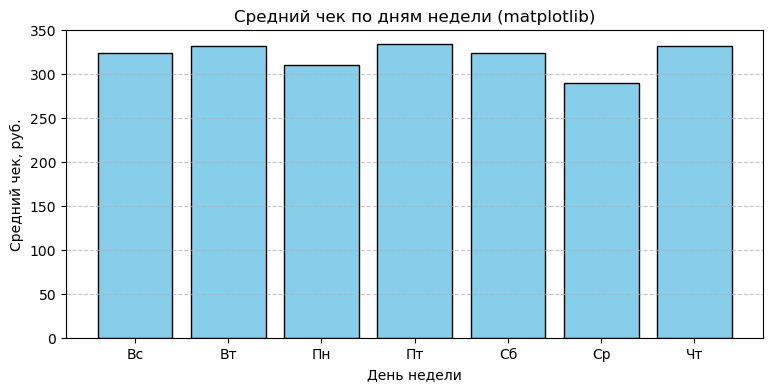

In [6]:
fig, ax = plt.subplots(figsize=(9, 4))

ax.grid(axis='y', linestyle='--', alpha=0.7)

ax.bar(days, values, color='skyblue', edgecolor='black')

ax.set_xlabel('День недели')
ax.set_ylabel('Средний чек, руб.')
ax.set_title('Средний чек по дням недели (matplotlib)')

plt.show()

Код рабочий. Но он требует от нас ручного вычисления статистики, явного извлечения массивов и настройки каждого элемента декора. А теперь представьте, что нам нужны не 7 дней недели, а 30 дней месяца, или что нужно добавить доверительные интервалы. Объём кода начнёт расти лавинообразно.

#### Подход seaborn (все вычисления — под капотом)

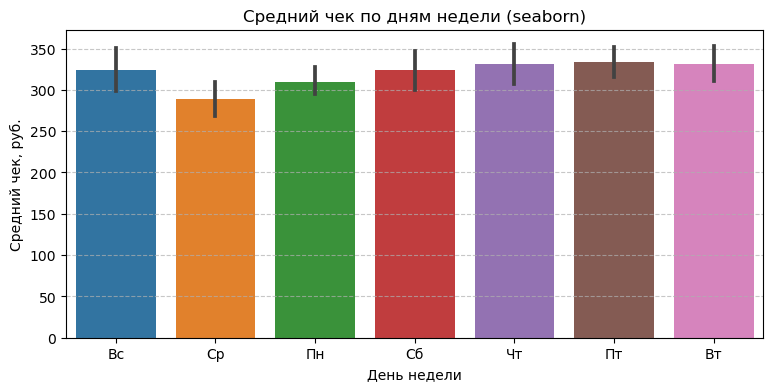

In [7]:
fig, ax = plt.subplots(figsize=(9, 4))

ax.grid(axis='y', linestyle='--', alpha=0.7)

sns.barplot(data=df, x='weekday', y='order_total')

ax.set_xlabel('День недели')
ax.set_ylabel('Средний чек, руб.')
ax.set_title('Средний чек по дням недели (seaborn)')

plt.show()

Seaborn сам нашёл средние, нарисовал столбцы, добавил доверительные интервалы (чёрточки сверху) и подписал оси названиями колонок. Единственное, что нужно было сделать — указать, где данные и какие колонки использовать.

Заметим, однако, что дни недели, скорее всего, расположатся в алфавитном порядке. Если нам нужен хронологический порядок, потребуется небольшая подготовка данных: превратить колонку weekday в категорию с заданным порядком. Но это делается один раз, до построения графика, и не влияет на лаконичность визуализации.

### Пример 2. Линейный график: динамика продаж по часам

Теперь другая задача: посмотреть, как меняется число клиентов по часам в течение дня. У нас есть колонка `'hour'` (час совершения покупки).

#### Подход matplotlib (снова вручную)

Нам нужно:

1) сгруппировать по часам и посчитать количество клиентов,
2) извлечь часы и счетчики,
2) построить линию.

Выполняем группировку и выводим индекс в виде самостоятельного столбца:

In [8]:
instruction = {'client_id':'count'}
hourly_counts = df.groupby('hour').agg(instruction)
hourly_counts = hourly_counts.reset_index(drop=False)
hourly_counts

,hour,client_id
0,6,51
1,7,52
2,8,44
3,9,24
4,10,26
5,11,23
6,12,26
7,13,31
8,14,28
9,15,38


Извлекаем данные (часы и счетчики):

In [9]:
hours = hourly_counts['hour']
counts = hourly_counts['client_id']

Строим график:

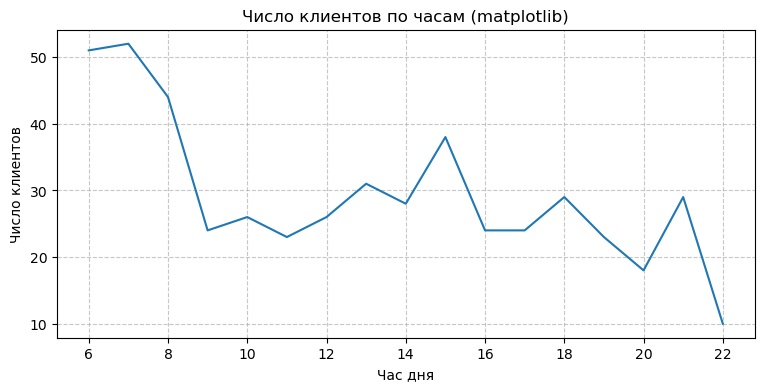

In [10]:
fig, ax = plt.subplots(figsize=(9, 4))

ax.grid(linestyle='--', alpha=0.7)

ax.plot(hours, counts, linestyle='-')
ax.set_xlabel('Час дня')
ax.set_ylabel('Число клиентов')
ax.set_title('Число клиентов по часам (matplotlib)')

plt.show()

Код снова требует ручной агрегации. Кроме того, если мы захотим построить на одном графике несколько кривых (например, для будних и выходных отдельно), код станет ещё более громоздким, и придётся вручную вызывать `plot` для каждой группы.

#### Подход seaborn (элегантный и гибкий)

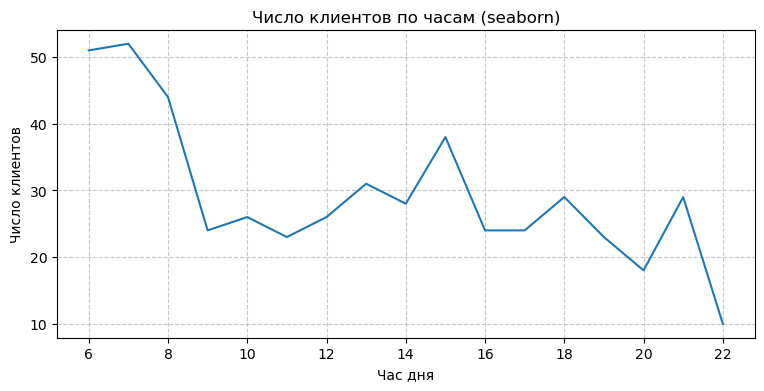

In [11]:
fig, ax = plt.subplots(figsize=(9, 4))

ax.grid(linestyle='--', alpha=0.7)

sns.lineplot(data=df, x='hour', y='client_id', estimator='count', errorbar=None)

ax.set_xlabel('Час дня')
ax.set_ylabel('Число клиентов')
ax.set_title('Число клиентов по часам (seaborn)')

plt.show()

Seaborn автоматически сгруппировал данные по часам, посчитал количество заказов и нарисовал линию с доверительным интервалом. Параметр `estimator='count'` указывает, что по оси Y откладывается количество записей.


Более того, если мы добавим параметр `hue` для разделения по дням недели, seaborn построит несколько линий на одном графике автоматически:

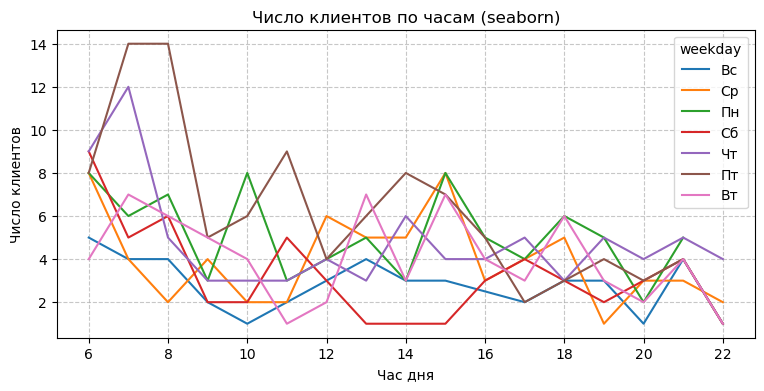

In [12]:
fig, ax = plt.subplots(figsize=(9, 4))

ax.grid(linestyle='--', alpha=0.7)

sns.lineplot(data=df, x='hour', y='client_id', hue='weekday', estimator='count', errorbar=None)

ax.set_xlabel('Час дня')
ax.set_ylabel('Число клиентов')
ax.set_title('Число клиентов по часам (seaborn)')

plt.show()

В matplotlib для этого пришлось бы писать цикл по дням и вызывать `plot` для каждого — а это уже десятки строк кода.

### Краткое резюме


Эти примеры иллюстрируют главную идею: seaborn не отменяет matplotlib, а надстраивается над ним. Он берёт на себя рутинные операции — агрегацию, подписи, цвета, статистические оценки — и позволяет сосредоточиться на анализе данных, а не на настройке графиков.

В следующем параграфе мы систематически разберём основные типы графиков seaborn и научимся настраивать их внешний вид. А пока — запомните простую рекомендацию: если вы хотите быстро понять, что происходит в данных — начинайте с seaborn, если нужен полный контроль над каждым пикселем — дорабатывайте в matplotlib.

## § 2. Три кита визуального разведочного анализа

Знаете, в чём главная проблема, когда новичок открывает seaborn в первый раз? Он видит сотню функций, у него разбегаются глаза, он начинает тыкаться во всё подряд, и к концу занятия у него в голове каша, а на экране — двенадцать одинаковых гистограмм разного цвета.

Мы пойдем по другому пути. Мы не станем заучивать названия функций, но попытаемся понять их логику.

Разработчики seaborn придумали гениальную вещь: для быстрых графиков они разбили все типы визуализаций на три большие группы. Три кита, на которых стоит вся библиотека быстрого визуального анализа. И если мы поймём содержание этих китов — мы перестанем блуждать в потёмках. Мы будем точно знать, какую функцию открыть, когда нам нужно будет ответить на конкретный вопрос. Вот они, наши киты.

### Кит первый: Relational plots — «Как одно связано с другим?»

Представим, что у нас есть две числовые переменные. Например, количество выпитых чашек кофе и уровень тревожности перед экзаменом (шутка, но не совсем). И мы хотим понять: есть ли между ними связь? Растёт ли одно вместе с другим? Или наоборот — падает? Или связь отсутствует?

Это — задача для `relplot`, семейства, внутри которого есть два базовых подхода. Вот эти базовые истории:

**Scatter plot (точки).** Здесь каждая точка — это одно наблюдение. Мы смотрим на облако точек и видим: есть ли тенденция? Разброс? Выбросы? Если точки собираются в какую-то линию — значит, связь есть. Если разбросаны как попало — связи, скорее всего, нет.


**Line plot (линия).** Здесь мы соединяем точки линией. Это удобно, когда у нас есть временной ряд или какая-то последовательность. Например, продажи по дням недели. Линия сразу покажет: где пик, где провал, есть ли тренд.

Магия начинается, когда мы добавляем параметр `hue`. Это третий признак, который раскрашивает точки или линии в разные цвета. Теперь мы смотрим не просто «связь между X и Y», а «как эта связь выглядит для мужчин и для женщин?» или «для участников программы лояльности и для обычных посетителей?». Двумерная картинка становится трёхмерной. 

Врубаем магию:

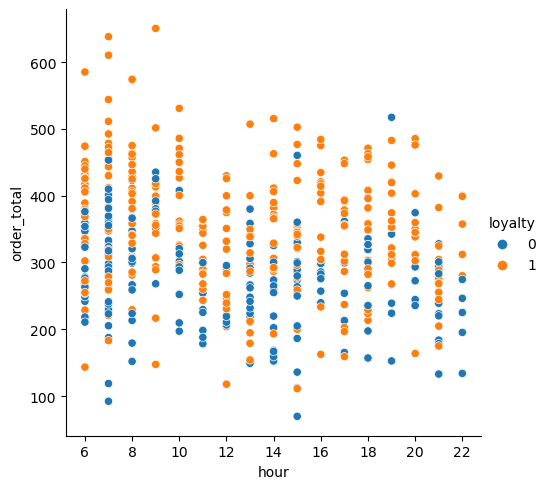

In [13]:
sns.relplot(data=df, x='hour', y='order_total', hue='loyalty', kind='scatter')

Всё. Одна строчка. А сколько в ней смысла: мы видим, как меняется средний чек в течение дня, и сразу разделяем клиентов на две группы. Чёрное и белое. Свои и чужие. Лояльные и не очень.

>#### Задание
Параметр `kind` помимо значения `scatter` имеет еще одно значение: `line`. Примените его и объясните получившийся график. Какой из вариантов более информативен? Почему?

In [14]:
# Код

### Кит второй: Distribution plots — «Как часто встречается каждое значение?»

Вопрос: сколько клиентов тратят до 500 рублей? Сколько — от 500 до 1000? А сколько — больше 2000? Одним числом (средним) тут не отделаться. Нужно распределение.

Здесь на сцену выходит `displot`. Внутри него — три мощных инструмента.

**Гистограмма.** Классика. Разбиваем ось X на корзины (`bins`) и считаем, сколько наблюдений попало в каждую. Чем выше столбик — тем больше людей (или кофеен, или продаж) в этом диапазоне. Визуально — это «ступеньки», которые показывают, где данные сгущаются, а где редеют.

**KDE (Kernel Density Estimation)** — сглаженный график плотности. Это та же гистограмма, только «причёсанная». Вместо угловатых ступенек — плавная линия, похожая на колокол. Почему это круто? Потому что колокол — это красиво. Потому что за колоколом стоит кривая Гаусса, а она — королева статистики. Когда студент видит на своих данных колокол — он чувствует себя древнегреческим богом анализа данных. И правильно делает. Потому что KDE — это его способ сказать миру: «Я вижу структуру там, где другие видят мусор».

**Histplot + KDE вместе.** Seaborn позволяет наложить линию плотности поверх гистограммы. Это как смотреть на чертёж здания и одновременно на его фотографию. Лучше и не придумать.

Например:

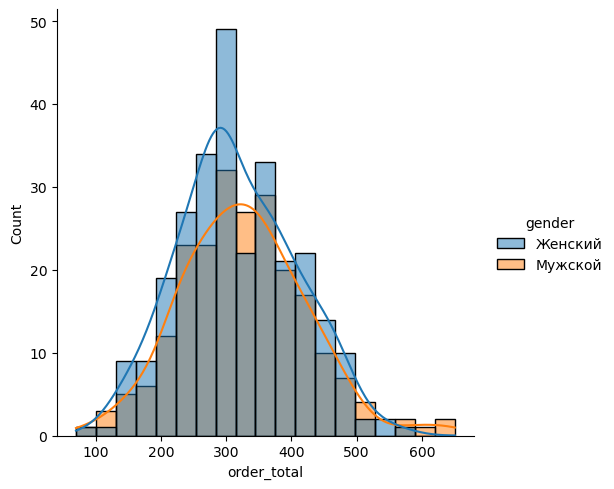

In [15]:
sns.displot(data=df, x='order_total', hue='gender', kde=True)

Снова `hue`. Мы уже не просто смотрим на распределение чека — мы смотрим, как оно различается у мужчин и женщин. И если «колокол» мужчин смещён влево, а женщин — вправо, мы уже подозреваем неладное. 

>#### Задание
Метод `displot` в `seaborn` обладает параметром `kind` Его возможные значения —  `'hist'`, `'kde'` и `'ecdf'`. Примените эти параметры к графику и объясните результаты.

In [16]:
# Код

### Кит третий: Categorical plots — «Сравниваем группы»

Вот здесь начинается самое мясо для экономистов, маркетологов и всех, кто работает с категориями. У нас есть категориальный признак (например, день недели: Пн, Вт, Ср…) и числовой (средний чек). Как сравнить эти группы?

Можно тупо посчитать средние, но это скучно. Seaborn даёт нам красоту.

**Boxplot — ящик с усами.** Мы видим прямоугольник (ящик), внутри которого — медиана и межквартильный размах (50% данных). Усы тянутся до границ, за которыми начинаются выбросы. Это моментальный рентгеновский снимок группы: симметрична ли выборка? Есть ли «хвосты»? Выскакивают ли аномалии за пределы?

**Violin plot — скрипичный график.** Почему он круче обычного ящика? Потому что он соединяет boxplot и KDE. Мы получаем и «ящик с усами» внутри, и сглаженное распределение по форме, напоминающей скрипку. Чем шире «скрипка» — тем больше данных в этом диапазоне. Это уже не просто рентген, это 3D-модель кровеносной системы группы. Красиво, информативно и современно.

**Bar plot — столбчатая диаграмма для средних.** Иногда не нужны сложности. Иногда достаточно показать столбик среднего чека по дням недели. И добавить планки погрешностей. Bar plot — это наш друг для докладов на совещаниях: «Видите, в пятницу средний чек выше. Мы молодцы».


Пример:

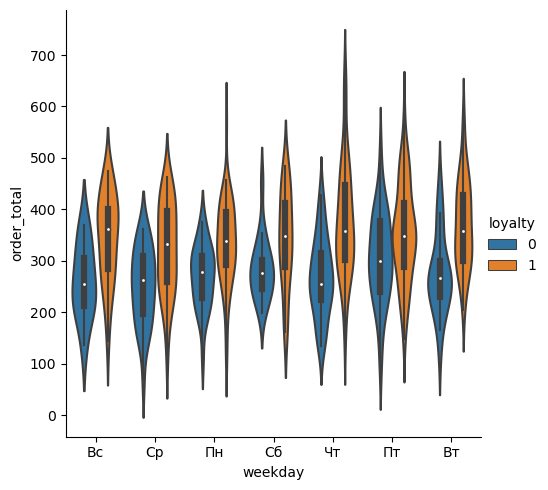

In [17]:
sns.catplot(data=df, x='weekday', y='order_total', kind='violin', hue='loyalty')

Одна строчка. А на выходе — четырнадцать скрипок (по семи дням недели, каждая разделена по цвету на лояльных и обычных). Мы видим: в пятницу вечером у лояльных «скрипка» толще в правой части — они тратят заметно больше. 

>#### Задание
Пaраметр `kind` метода `catplot` может принимать следующие значения:
`'strip'`, 
`'swarm'`,
`'box'`,
`'violin'`,	
`'boxen'`,
`'point'`,	
`'bar'`.
В цикле по этим параметрам выведите графики и прокомментируйте результаты.

In [18]:
# Код

### Краткое резюме


- **Relplot** — связи и зависимости. Must have для начала любого анализа.
- **Displot** — распределения и «колокола Гаусса». Для тех, кто хочет знать, как на самом деле живут данные.
- **Catplot** — сравнение групп. Для тех, кто принимает решения.

И везде — `hue`. Один маленький параметр, который превращает вашу плоскую картинку в многомерную историю. Научитесь выбирать кита под свой вопрос — и Seaborn станет вашим родным языком. А не набором чужих непонятных слов.

## § 3. Оси, размеры и экспорт

Мы научились рисовать. Теперь — научимся делать так, чтобы это не выглядело как черновик.

Seaborn, в отличие от matplotlib, умеет сам подписывать оси — он просто берёт названия столбцов из датафрейма. Это удобно. Но иногда названия столбцов выглядят так, будто их придумывал программист в три часа ночи: `is_friday_evening`, `drink_category`, `order_total`. Согластесь, `order_total` — ещё куда ни шло. А вот `is_friday_evening` на графике смотрится так, будто мы забыли перевести интерфейс с машинного на человеческий.

Здесь мы научимся:

1. подписывать оси как люди,
2. изменять размеры и пропорции холста
3. и сохранять картинку так, чтобы её не стыдно было вставить в отчет.

Для начала — сделаем базу, чтобы было что «причёсывать». Для этого построим «сырой» график: красивый, но без подписей.

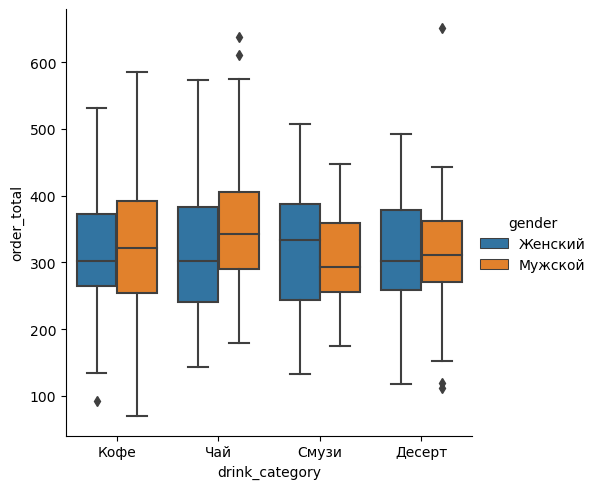

In [19]:
sns.catplot(data=df, x='drink_category', y='order_total', hue='gender', kind='box')

### Подписываем оси

В Seaborn оси можно родписать при помощи  `set_xlabel` и `set_xlabel` как и в matplotlib. Но. Так можно поступать, если мы работаем с обычными методами, ткаими как `barplot`, `lineplot` или `scatterplot` (см. § 1). 

А вот с тремя китами — `relplot`, `displot`, `catplot` — так поступать нельзя. Seaborn так не умеет. После команды `sns.catplot` он создает объект `g`. И это не просто график, это — «сетка графиков». Даже если график один, он всё равно внутри этой сетки. Поэтому, чтобы добраться до осей — используется `g.set_axis_labels`.


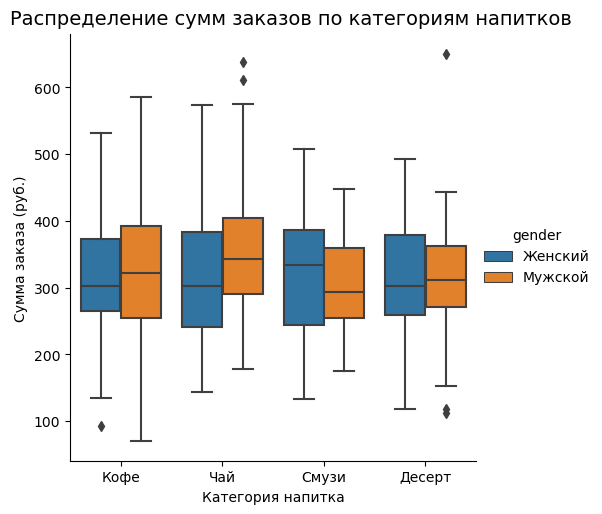

In [20]:
g = sns.catplot(data=df, x='drink_category', y='order_total', hue='gender', kind='box')

g.set_axis_labels('Категория напитка', 'Сумма заказа (руб.)')
g.fig.suptitle('Распределение сумм заказов по категориям напитков', y=1.02, fontsize=14)

plt.show()

### Изменяем размер и пропорции

Методы `relplot`, `displot`, `catplot` — это Figure-level функции. Они не рисуют на существующем холсте. Они сами создают свой собственный холст. Целиком. С нуля. И плевать они хотели на наш привычный `plt.figure(figsize=(9,4))` — они его просто игнорируют, потому что у них внутри свой `plt.subplots`.

Это сделано специально, чтобы студент (или аналитик) мог одной строкой получить красивое полотно с легендой, с сабплотами, с правильным разрешением — и не думать о том, как это устроено.

Но у этого есть цена: мы теряем контроль.


Хотите поменять размер? Передайте `height=` и `aspect=` прямо в функцию. Не через `figsize`, а вот так:

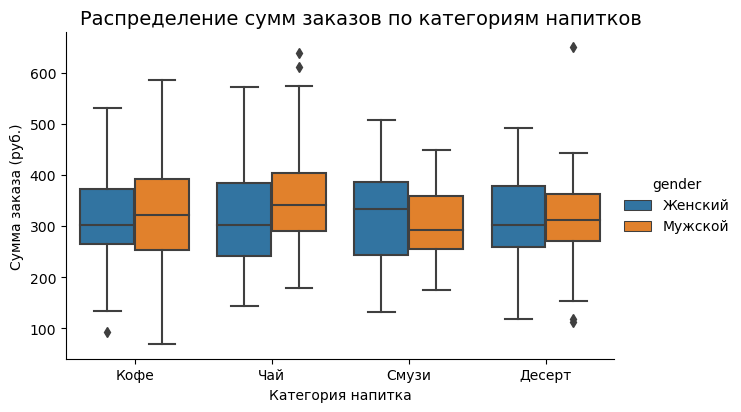

In [21]:
g = sns.catplot(data=df, x='drink_category', y='order_total', hue='gender', kind='box', height=4, aspect=1.6)

g.set_axis_labels('Категория напитка', 'Сумма заказа (руб.)')
g.fig.suptitle('Распределение сумм заказов по категориям напитков', y=1.02, fontsize=14)

plt.show()

Здесь `height` — высота одного графика (в дюймах), а `aspect` — отношение ширины к высоте. Контролируемо, хотя и непривычно. А если вы хотите встроить эти методы свой `fig`, `ax`, то ничего не выйдет, потому что они не Axes-level. Они Figure-level.

### Сохраняем для презентации

График на экране — это одно. График в презентации на проекторе — совсем другое. Низкое разрешение (72 DPI) превращает тонкие линии в пиксельную кашу, в тот момент как высокое (300 DPI) даёт чёткую картинку даже на большом экране. Сохранение графиков из seaborn ничем не отличается от аналогичной операции из matplotlib. Важно лишь не забывать формулу счастья.

**Формула счастья:** `plt.savefig('filename.png', dpi=300, bbox_inches='tight')`


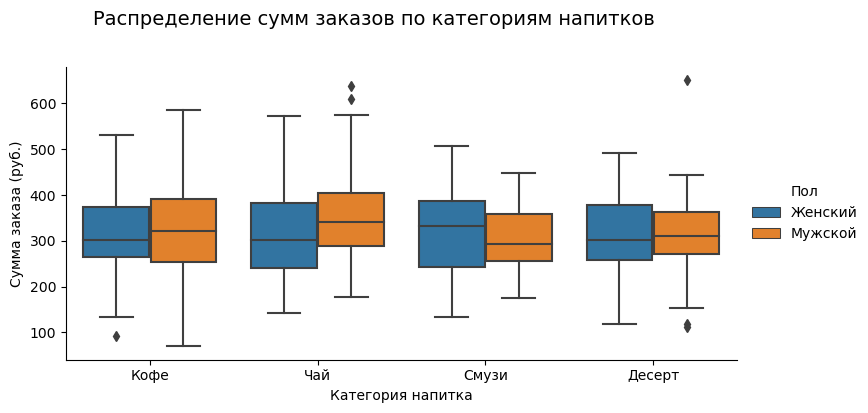

In [22]:
g = sns.catplot(
    data=df,
    x='drink_category', y='order_total',
    hue='gender',
    kind='box',
    height=4, aspect=1.6
)

g.set_axis_labels('Категория напитка', 'Сумма заказа (руб.)')
g.fig.suptitle('Распределение сумм заказов по категориям напитков', y=1.02, fontsize=14)

g._legend.set_bbox_to_anchor((1.15, 0.5))
g._legend.set_title('Пол')

plt.tight_layout()

plt.savefig('boxplot_orders_by_drink.png', dpi=300, bbox_inches='tight')

plt.show()

>#### Задание
Пaраметр `kind` метода `catplot` может принимать следующие значения:
`'strip'`, 
`'swarm'`,
`'box'`,
`'violin'`,	
`'boxen'`,
`'point'`,	
`'bar'`.
В цикле по этим параметрам выведите графики в фалы png. Размеры изображения: ширина 9 дюймов, высота 4 дюйма. Разрешение изображения 300 dpi.

In [23]:
# Код

### Краткое резюме

Весьма уместные при проведении быстрого разведочного анализа методы `relplot`, `displot`, `catplot` вряд ли следует рассматривать, как инструменты, пригодные для полноwенной полиграфии или web'а. Они обладают параметрами настройки, но доступ к ним затруднен и непривычен. Поэтому, в качестве наиболее удобной схемы визуализации обычно рассматривают гибридную схему: с конструкциями типа `fig, ax = plt.subplots` и командами из библиотеки seaborn (такие схемы были рассмотрены в § 1).

## §4. Контексты и стили

Итак, мы уже умеем рисовать. Не Айвазовские, конечно, но Малевичу с его квадратами до нас точно далеко — мы умеем рисовать вещи посложнее квадратов, и наши три кита нас не подводят: `relplot`, `displot`, `catplot`. Мы знаем, как сохранить график и как настроить оси (пусть и с трудом — об этом мы честно говорили выше).

Но есть один секрет, который превращает человека, рисующего графики, в визуального коммуникатора. Это — умение выбирать стиль и контекст.

### Визуальный этикет

Представим три ситуации.

Первую из них мы знаем лучше всего: это наш Jupyter Notebook. мы сидим, исследуем данные. мы смотрим на гистограмму и думаем: «Так, тут явно выброс. Надо удалить». При этом нам абсолютно не важно, какой у нас выстален шрифт, какая толщина линии и есть ли сетка. Эти графики — наши рабочие черновики. Они не обязаны быть красивыми. Они обязаны быть быстрыми.

Вторая ситуация — научная статья или отчёт. Здесь мы показываем результат другим людям. Поэтому наши графики должны быть строгими, чистыми и, по возможности, профессиональными. Сетка — тонкой. Подписи — чёткими. Ничего лишнего, никаких ярких цветов «на любителя». Потому что это — наш выход в свет. Мы рисуем не для себя, мы рисуем для коллег и рецензентов.

Третья ситуация — презентация, а в зале сидят 50 человек, которые видят наши результаты первый раз и через 10 секунд забудут. То есть, за 10 секунд визуального контакта нам нужно добиться если не восторга, то хотя бы понимания. Еще неплохо было бы, чтобы те, кто сидит на последнем ряду, тоже увидели бы наши линии и прочитали бы наши надписи. Это значит — линии должны быть жирными, шрифты — крупными. Потому что это — публичное выступление.

Ну и бонусом — четвёртая ситуация: блог или пост в соцсетях. Тут можно и нужно быть и ярким, и необычным, и привлекающим внимание, и вообще каким угодно (все равно наш блог никто не читает). Но об этом — чуть позже.

>#### Вопрос
Как вы думаете, сколько времени вы потратите, если вам нужно переделать один и тот же график из «рабочего черновика» в «строгий отчет», а потом в «презентационный формат»? Подсказка: вспомните, как мы мучились с настройками matplotlib на прошлой лекции.

А теперь ответ: с помощью обычного matplotlib — это 15–20 минут танцев с бубном. С помощью seaborn — одна строчка.

### Идеология управления средой

В Matplotlib мы привыкли, что каждый штрих нужно наносить вручную. Seaborn работает иначе: он создает среду. Представим, что мы заходим в комнату: мы можем перекрасить стены, сменить освещение или попросить всех говорить погромче (или, что более вероятно, попросить всех заткнуться).

В Seaborn за это отвечают три независимых рычага. Давайте разберем их логику.

#### Стили интерфейса (`sns.set_style`) — «Декорации»

Это то, как выглядит «холст», на котором мы рисуем. В Seaborn есть пять стандартных пресетов, которые меняют фон и сетку:

- **darkgrid** (по умолчанию): Серый фон, белые линии сетки. Хорошо для глаз, когда данных много.

- **whitegrid**: Белый фон с серой сеткой. Идеально для тяжелых отчетов, которые будут печатать на принтере (экономим картридж!).

- **dark**: Просто серый фон без сетки. Минимализм.

- **white**: Просто белый холст. Самый строгий вариант.

- **ticks**: Белый холст с маленькими рисками (черточками) на осях. Классический вид из научных журналов.


Логика такого разделения состоит в том, что стили отвечают за эстетику. Они не меняют размер шрифта или толщину линий, они только «интерьер».

#### Контексты (`sns.set_context`) — «Масштаб аудитории»

Это, пожалуй, самая крутая фишка, потому что контекст меняет размер всех элементов сразу: толщину линий, размер шрифта подписей, размер точек и т. д.

- **paper**: Тонкие линии, мелкий шрифт. Для чтения с листа или экрана ноутбука вплотную.

- **notebook** (по умолчанию): Чуть крупнее, сбалансировано для работы в .ipynb.

- **talk**: Жирные линии, крупные буквы. Идеально для презентаций, когда люди смотрят на экран с расстояния 5–10 метров.

- **poster**: Гигантские элементы. Для огромных плакатов на конференциях.

На этот раз логика в том, что контекст — это вопрос физической видимости. Вам не нужно менять `fontsize=14` у каждой оси, вы просто говорите: «Я выступаю на презентации» (`set_context("talk")`), и Seaborn сам всё увеличивает.

#### Цветовые палитры (`sns.set_palette`) — «Настроение»

Цвета в Seaborn — это не просто выбор «красный или синий». Это способ подчеркнуть смысл данных.

- **Качественные (Qualitative)**: Для разных категорий (например, "Чай" и "Кофе"). Цвета должны быть максимально контрастными.

- **Последовательные (Sequential)**: Для числовых данных (например, от маленького чека к большому). Цвет плавно переходит от светлого к темному.

- **Расходящиеся (Diverging)**: Если есть «ноль» или среднее значение (например, температура: от синего через белый к красному).

Палитры Seaborn продуманы так, чтобы работать в этих трёх режимах, и это очень удобно, когда выбираешь цвета осмысленно, а не просто хватаешь первый попавшийся. Другими словами, Seaborn — это про элегантность и продуманность (а Matplotlib — про «сделай сам»).

### Два режима управления

Есть два способа применить эти настройки.

#### Глобальный

Один раз в начале ipynb (можно вообще — в ячейче импортов) пишем:


```python
sns.set_theme(style='whitegrid', context='talk', palette='muted')
```
С этого момента все последующие графики в ноутбуке будут выглядеть именно так. Это удобно для поддержания единого стиля всей работы.

#### Локальный

Если мы почему-то хотим, чтобы один график был в стиле «poster» (интересно, зачем нам это?), а остальные остались обычными (это не вполе разумное желание), используется конструкция with:


```python
with sns.axes_style("dark"):
    # Рисуем график — он будет на сером фоне
    sns.lineplot(...) 
# Следующий график снова будет обычным

```

### Заглядываем под капот

Возникает естественный вопрос: «А откуда Seaborn берет эти настройки? У него есть магический шар?». Ответ — да, есть. Но это страшная тайна, доступная немногим.

Помните, мы говорили, что Seaborn — это надстройка над Matplotlib? Так вот, у Matplotlib есть огромный словарь настроек, который называется rcParams. 
Когда мы вызываем `sns.set_theme()`, Seaborn идет в этот словарь и массово меняет там десятки параметров: `axes.linewidth`, `xtick.labelsize`, `font.family` и т. д. 

**Важное правило.** Если вы вручную настроили что-то через Matplotlib (`plt.rcParams`), а потом вызвали `sns.set_theme()`, Seaborn «переедет» ваши настройки своими. Поэтому следует поступать в обратной последовательности: сначала задаем общую тему Seaborn, а потом, если нужно, «допиливаем» мелочи через Matplotlib.

**Еще более важное правило.** Если вы не знаете, какие цвета выбрать — не выбирайте. Просто напишите:


```python
sns.set_palette("husl")
```
  
Библиотека сделает всё за вас. Если же вы художник в душе — лезьте в документацию Seaborn и выбирайте из трёх групп: Qualitative, Sequential, Diverging. Но не пытайтесь смешивать стили Matplotlib и палитры Seaborn вручную — запутаетесь сами и запутаете график.



### Несколько примеров

#### Пример 1. Базовый: «Доверься Seaborn!»

Ничего не знаем про дизайн. Просто смотрим на категории напитков.

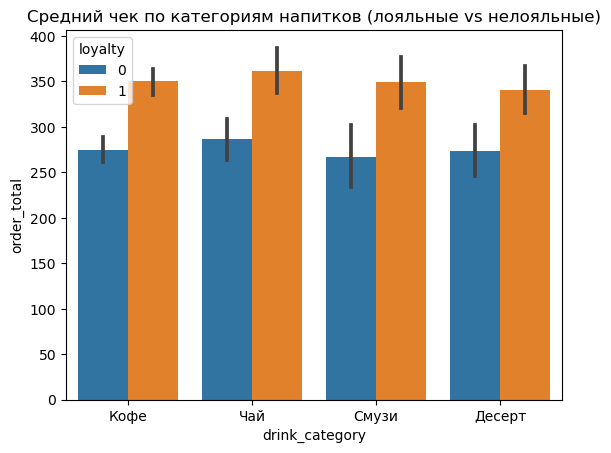

In [24]:
sns.barplot(data=df, x="drink_category", y="order_total", hue="loyalty")
plt.title("Средний чек по категориям напитков (лояльные vs нелояльные)")
plt.show()

Что сделал Seaborn? — использовал дефолтную палитру `'tab10'`, увидел две категории по `'loyalty'` и покрасил их в синий и оранжевый цвета. Работает. Без паники. 

#### Пример 2. Категориальные данные — Qualitative

У нас четыре категории товаров: `'Кофе'`, `'Чай'`, `'Смузи'`, `'Десерт'`. Они неупорядочены. Поэтому берем палитру `'Set2'` — безопасные пастельные тона.

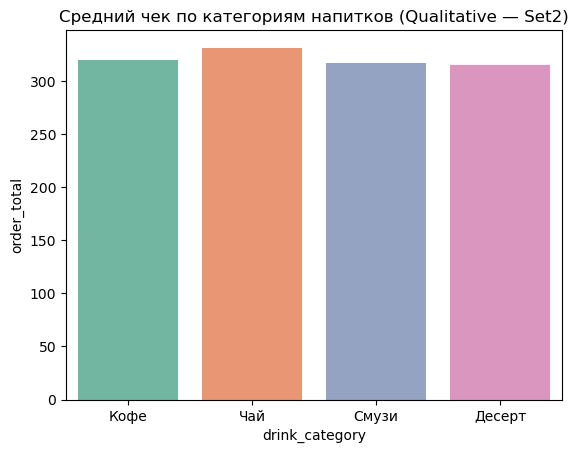

In [25]:
sns.set_palette("Set2")

sns.barplot(data=df, x="drink_category", y="order_total", errorbar=None)
plt.title("Средний чек по категориям напитков (Qualitative — Set2)")
plt.show()


Seaborn достал из `'Set2'` первые четыре цвета и раскрасил столбцы. Красиво — и никакого ложного порядка. Вуаля.

#### Пример 3. Порядковые данные — Sequential

Теперь добавляем числовую колонку. Хотим увидеть, как возраст влияет на сумму заказа и для этого используем палитру `'viridis'`.


Делаем точечный график:

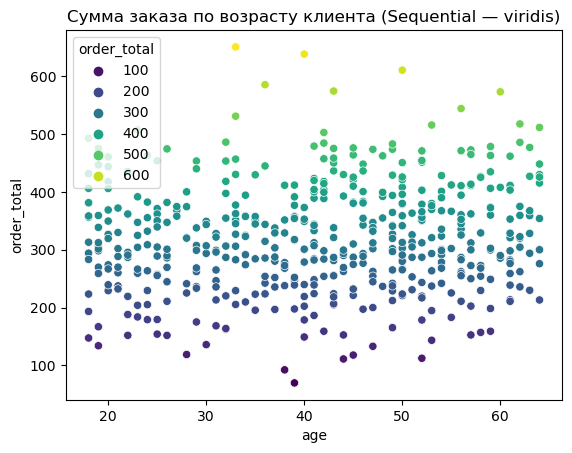

In [26]:
sns.scatterplot(data=df, x="age", y="order_total", hue="order_total", palette="viridis")
plt.title("Сумма заказа по возрасту клиента (Sequential — viridis)")
plt.show()

Чем выше сумма заказа — тем точка темнее. Seaborn сам построил градиент.

#### Комментарий к примерам 2 и 3

Почему мы в примере 2 использовали метод `sns.set_palette('Set2')`, а в примере 3 — параметр `palette='viridis'`? Всё дело в глобальном vs локальном действии.

Код `sns.set_palette('Set2')` — это глобальная настройка. Когда мы пишем:


```python
sns.set_palette('Set2')
```

 — мы говорим Seaborn'у: «Отныне и до конца сессии (или до следующей переустановки) используй эту палитру для всех графиков, если я не скажу иначе».

Это удобно, когда у нас много графиков подряд, и мы хотим, чтобы все они были в едином стиле. Например, в начале ноутбука поставили `'sns.set_palette('Set2')'` — и все `'barplot'`, `'boxplot'`, `'stripplot'`, которые идут дальше, автоматически используют эти пастельные тона. Без лишних параметров. Но есть тонкость: `'sns.set_palette()'` влияет **только на категориальные графики** (где цвета назначаются по категориям). Для числовых градиентов (как в `scatterplot` с `hue`) этот метод не работает — там нужно указывать палитру явно через параметр palette.


Код  `'palette="'viridis'` — это локальная настройка. Когда мы пишем

```python
sns.scatterplot(..., palette='viridis')
```
— мы говорим Seaborn'у: «Только для этого конкретного графика используй палитру `'viridis'`. Следующий график — забудь про нее и вернись к глобальной настройке (если она была)». Здесь `palette` — это параметр конкретной функции. Он переопределяет глобальную палитру только для этого вызова.

Так почему же мы не использовали `sns.set_palette('viridis')` для второго графика? Потому что это не сработало бы. `sns.set_palette()` рассчитана на дискретные (категориальные) палитры. Когда мы подаем в `hue` числовую колонку, Seaborn автоматически понимает, что нужен градиент, и требует указать палитру через параметр palette.

Если бы мы написали:

```python
sns.set_palette('viridis')
sns.scatterplot(data=df, x='age', y='order_total', hue='order_total')
```
— Seaborn бы проигнорировал глобальную настройку и использовал дефолтную последовательную палитру. Или вообще выдал бы ошибку.

**Вывод.** Глобальный метод `sns.set_palette()` — для категорий и стиля всей сессии. Локальный параметр `palette=` — для конкретного графика, особенно если данные числовые и нужен градиент. Не путайте, иначе возможны сюрпризы.

### Демонстрация: 5 стилей × 4 контекста

Для наглядности возьмём один из наших графиков — например, тот самый scatterplot с возрастом и суммой заказа, где цвет показывает величину чека. И прогоним его через разные комбинации.

<!-- Вот код, который показывает все 20 вариантов сразу: -->

#### Вариант 1. darkgrid + poster

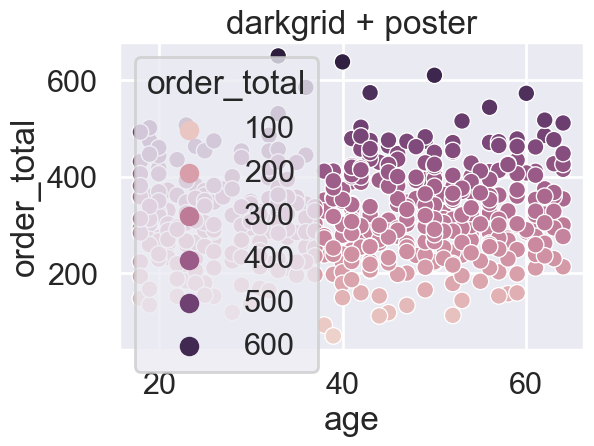

In [27]:
sns.set_context('poster')
sns.set_style('darkgrid')
plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x="age", y="order_total", hue="order_total")
plt.title('darkgrid + poster')
plt.show()

Что видим:

- фон тёмный с сеткой — серьёзно, научно, солидно,

- точки крупные, подписи огромные — видно с последнего ряда.

Когда уместно:

- презентация на конференции, где очень большой зал,

- скриншот, который будут смотреть с телефона,

- мы хотим, чтобы график выглядел «дорого и статусно».

#### Вариант 2. white + paper

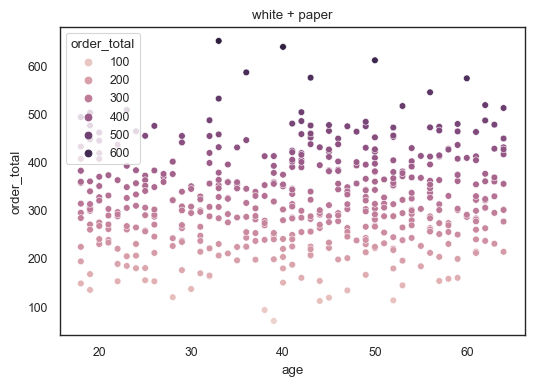

In [28]:
sns.set_context('paper')
sns.set_style('white')
plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x="age", y="order_total", hue="order_total")
plt.title('white + paper')
plt.show()

Что видим:

- белый фон, без сетки — минимализм, ничего лишнего;

- точки мелкие, шрифты маленькие — экономим место;

- есть только данные и оси.

Когда уместно:

- публикация в журнале,

- отчёт, где графиков много и они мелкие,

- нам нужно, чтобы читатель смотрел на данные, а не на украшения.

#### Вариант 3. ticks + talk

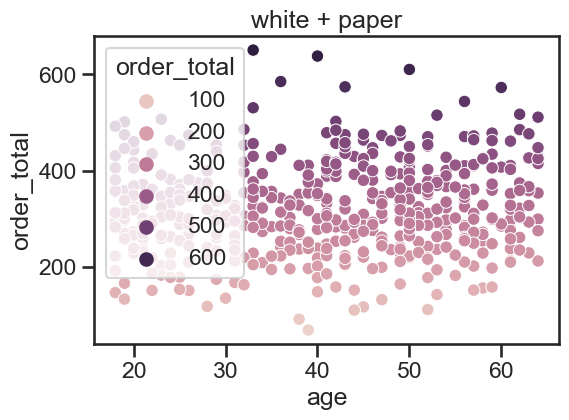

In [29]:
sns.set_context('talk')
sns.set_style('ticks')
plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x="age", y="order_total", hue="order_total")
plt.title('white + paper')
plt.show()

Что видим:

- белый фон, но есть метки на осях (ticks) — аккуратно, но без лишней сетки;

- Размер точек и шрифтов — средний, комфортный для чтения с экрана ноутбука или планшета;

- чисто, современно, без перегруза.

Когда уместно:

- лекция;

- блог-пост или статья;

- когда хочется выглядеть профессионально, но не давить пафосом.

>#### Задание 
Возьмите код и замените в нём стиль и контекст на любые другие (например, `'dark'` + `'notebook'` или `'whitegrid'` + `'poster'`). Запустите, посмотрите. Ответьте на вопросы.
>- Что изменилось? (Размер точек? Фон? Шрифты? Наличие сетки?)
>- Где этот вариант был бы уместен? (Презентация? Статья? Пост в соцсетях? Рабочий дашборд?)
>- А где — неуместен? (Например: для печати не хватит чёткости; или —  для большого зала слишком мелко)

#### Запомните главное
  
Seaborn — это не «сделай красиво». Это «сделай уместно». Хороший график — это не тот, где много цветов и теней. Это тот, который честно отвечает на вопрос исследователя и не мешает зрителю этот ответ увидеть. Палитра, стиль, контекст — это не украшения. Это инструменты настройки внимания. 

## § 5. От гипотез к инсайтам: когда данные начинают говорить

Ну что, коллеги, мы с вами уже не просто «рисуем картинки». Мы вооружились палитрами как скальпелями и контекстами как микроскопами. Настало время применить нашу магию к реальным бизнес-задачам. Знаете, в чем разница между простым аналитиком и крутым? Аналитик строит график, чтобы показать данные. Крутой специалист строит график, чтобы проверить догадку.
У нас есть датасет, есть интуиция и пара часов до дедлайна. Давайте побудем немного пророками.

### Гипотеза A: «Утренний кофе — это святое (и дорогое)»

#### Формулировка
Мы предполагаем, что утренний средний чек (с 6:00 до 10:00) выше, чем средний чек в остальное время дня.

#### Рассуждение
Почему так может быть? Утром люди спешат, берут «комбо», большие сеты или просто не экономят на завтраке, чтобы хоть как-то пережить этот понедельник. Как это проверить? Нам нужно не просто облако точек, нам нужна динамика. Нам нужно увидеть пульс нашего кафе по часам. И лучший инструмент здесь — `lineplot`. Он свяжет средние значения тонкой нитью и покажет нам общую тенденцию.

#### Иллюстрация

In [30]:
sns.set_context('notebook')
sns.set_style('whitegrid')

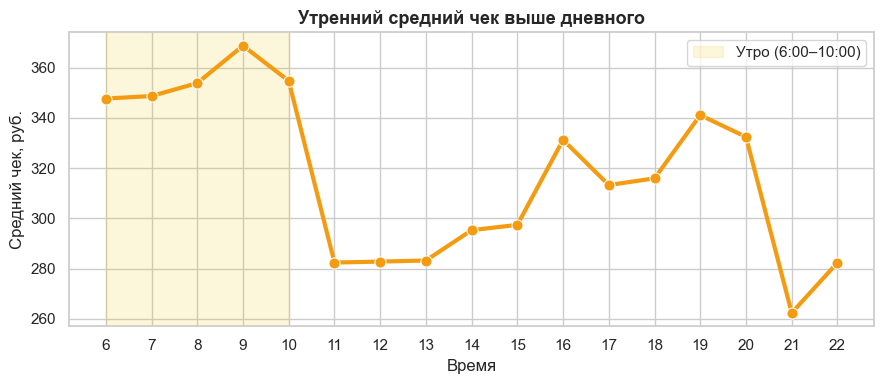

In [31]:
fig, ax = plt.subplots(figsize=(9, 4))

# Почасовые средние
hourly_mean = df.groupby('hour')['order_total'].mean().reset_index()

sns.lineplot(data=hourly_mean, x='hour', y='order_total',
             color='#F39C12', linewidth=3, marker='o', markersize=8, ax=ax)

# Подсветка утра
ax.axvspan(6, 10, alpha=0.15, color='#F1C40F', label='Утро (6:00–10:00)')

ax.set_xlabel('Время')
ax.set_ylabel('Средний чек, руб.')
ax.set_title('Утренний средний чек выше дневного', 
             fontsize=13, fontweight='bold')
ax.set_xticks(range(6, 23))
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

#### Вердикт
Ну что я говорил? (Я поправляю очки и стараюсь не слишком явно светиться от гордости). Посмотрите на этот горб в левой части графика. Мы с вами — просто аналитические гении. Интуиция нас не подвела: утренний чек действительно выше дневного затишья. Мы «проинтуитили» реальность и подтвердили её кодом. Брависсимо!

### Гипотеза B: «Пятничная магия, или почему в пятницу вечером всё иначе»

#### Формулировка
В пятницу вечером (с 18:00 до 20:00) средний чек значительно выше, чем в то же самое время в обычные будние дни.

#### Рассуждение
Пятница — это не просто день недели, это состояние души. В пятницу люди заказывают на компанию, берут десерты, празднуют выживание после рабочей недели. Чтобы это проверить, нам нужно столкнуть два мира: серые будни и фиолетовую пятницу. Мы наложим две линии друг на друга. Если они разойдутся — значит, магия существует.

#### Иллюстрация

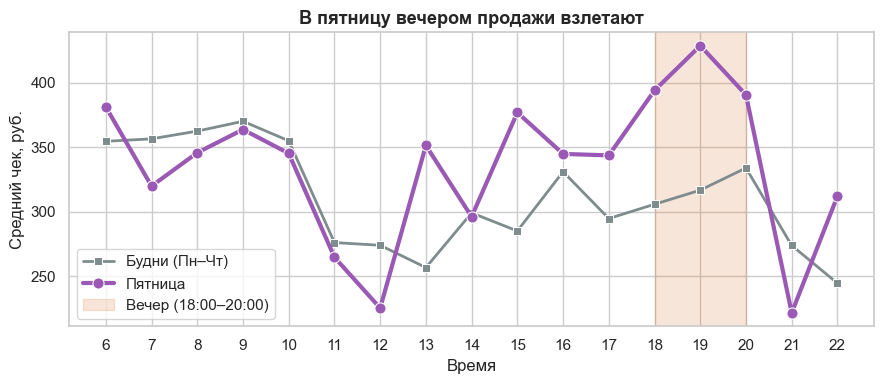

In [32]:
fig, ax = plt.subplots(figsize=(9, 4))

# Сравнение пятницы и будней
hourly_friday = df[df['weekday'] == 'Пт'].groupby('hour')['order_total'].mean().reset_index()
hourly_weekday = df[df['weekday'].isin(['Пн', 'Вт', 'Ср', 'Чт'])].groupby('hour')['order_total'].mean().reset_index()

sns.lineplot(data=hourly_weekday, x='hour', y='order_total', 
             color='#7F8C8D', linewidth=2, marker='s', markersize=6, label='Будни (Пн–Чт)', ax=ax)
sns.lineplot(data=hourly_friday, x='hour', y='order_total', 
             color='#9B59B6', linewidth=3, marker='o', markersize=8, label='Пятница', ax=ax)

ax.axvspan(18, 20, alpha=0.15, color='#D35400', label='Вечер (18:00–20:00)')

ax.set_xlabel('Время')
ax.set_ylabel('Средний чек, руб.')
ax.set_title('В пятницу вечером продажи взлетают', 
             fontsize=13, fontweight='bold')
ax.set_xticks(range(6, 23))
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

#### Вердикт
Видите этот разрыв? Это не просто графики, это звук открывающегося шампанского! Будни уныло ползут по низу, а пятница в 18:00 делает резкий апперкот вверх. Мы снова оказались правы. Когда данные так красиво ложатся под гипотезу — это и есть истинное удовольствие от работы.

## Домашнее задание

Коллеги, я немного устал быть гением в одиночку. Теперь ваша очередь. У нас остались еще две гипотезы, которые просто умоляют о том, чтобы их визуализировали так же изящно.

>#### Задание 1
Гипотеза C: «Программа лояльности — это не просто пластик». 
Докажите визуально, что участники программы лояльности тратят в среднем на 30% больше. Используйте barplot, добавьте доверительные интервалы (capsize) и обязательно подпишите точные значения над столбцами.
>
>#### Задание 2 
Гипотеза D: «Гендерное равенство в чеках».
Проверьте, правда ли, что мужчины и женщины тратят в нашем кафе примерно одинаково. Постройте сравнительный график. Подумайте, какой тип визуализации здесь будет самым честным?

Лучшие работы я… ну, я их просто похвалю.